## Make Figures
This notebook is for making figures used for slides

In [1]:
import sys
sys.path.append('../src')

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/lambda_5000000_1


/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


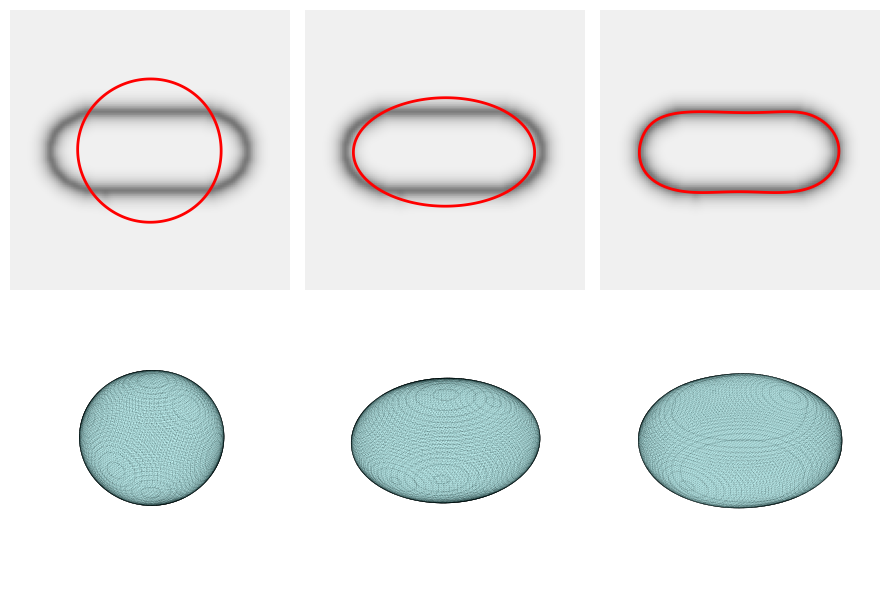

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 128
lambda_1 = 5000000
lambda_2 = 1
num_collocation = 1000
num_layers = 2
steps_to_visualize = [0, 100, 10000]
steps_series = list(range(0, 10001, 100))

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
mrc_file_path = "../data/synthetic/biconcave.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

# Plot figures
fig = plt.figure(figsize=(9, 6))

# Row 1: visualize_cryoET_with_contours
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(2, 3, i + 1)
    visualize_cryoET_with_contours(ax, step, checkpoint_data[step], cryoET_data, grid_size=GRID_SIZE, slice_index=64, axis="z", no_label=True)

# Row 2: plot_3d_isosurface
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(2, 3, 3 + i + 1, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, no_label=True)
    
plt.tight_layout()
# plt.savefig("../outputs/figs/analysis.png", dpi=300, bbox_inches="tight")
plt.show()

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/experimental/TS_105_7/lambda_1000000_100


/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Resizing MRC data from (64, 64, 64) to (128, 128, 128)


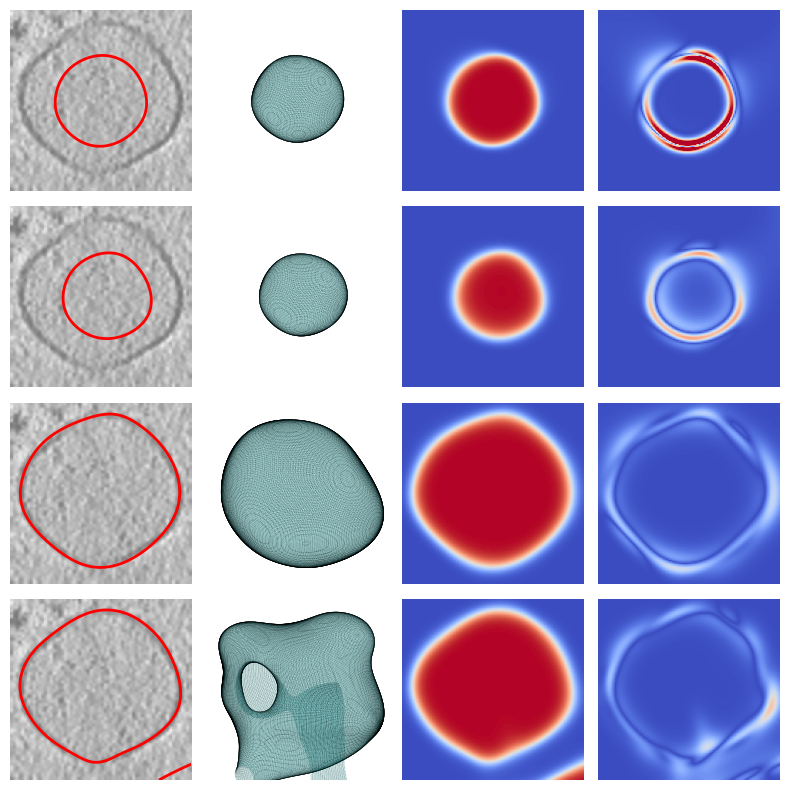

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
    visualize_physics_loss,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 128
lambda_1 = 1000000
lambda_2 = 100
num_collocation = 1000
num_layers = 2
steps_to_visualize = [0, 100, 1000, 10000]
steps_series = list(range(0, 10001, 100))
epsilon = 0.05

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/experimental/TS_105_7/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
# mrc_file_path = "../data/synthetic/biconcave.mrc"
mrc_file_path = "../data/experimental/downsampled/TS_105_7.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

col_len = len(steps_to_visualize)

fig = plt.figure(figsize=(2*4, 2*col_len))  # width × height in inches

for i, step in enumerate(steps_to_visualize):
    # Column 1: CryoET with contours
    ax1 = fig.add_subplot(col_len, 4, i*4 + 1)
    visualize_cryoET_with_contours(ax1, step, checkpoint_data[step], cryoET_data,
                                   grid_size=GRID_SIZE, slice_index=64, axis="x", no_label=True)

    # Column 2: 3D Isosurface
    ax2 = fig.add_subplot(col_len, 4, i*4 + 2, projection='3d')
    plot_3d_isosurface(ax2, step, checkpoint_data[step], grid_size=GRID_SIZE, no_label=True)

    # Column 3: Placeholder for your 3rd plot type
    ax3 = fig.add_subplot(col_len, 4, i*4 + 3)
    ax3 = visualize_physics_loss(ax3, epsilon=epsilon, 
                           checkpoint=checkpoint_data[step], component="phi",
                           grid_size=GRID_SIZE, slice_index=64, axis="x", vmin=-1, vmax=1, no_label=True)

    # Column 4: Placeholder for your 4th plot type
    ax4 = fig.add_subplot(col_len, 4, i*4 + 4)
    ax4 = visualize_physics_loss(ax4, epsilon=epsilon, 
                           checkpoint=checkpoint_data[step], component="residual",
                           grid_size=GRID_SIZE, slice_index=64, axis="x", vmin=0, vmax=150, no_label=True)

plt.tight_layout()
# plt.savefig("your_filename.png", dpi=300, bbox_inches="tight")
plt.show()



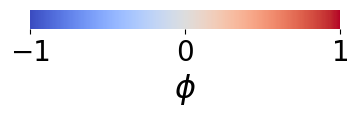

In [35]:
# standalone color bar

import matplotlib.pyplot as plt
import matplotlib.colorbar as colorbar
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Set color range
vmin = -1
vmax = 1

# Create a dummy ScalarMappable with a colormap and normalization
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.coolwarm  # or any other colormap, e.g., cm.coolwarm
sm = cm.ScalarMappable(norm=norm, cmap=cmap)

# Create a standalone figure just for the colorbar
fig, ax = plt.subplots(figsize=(4, 0.5))  # Adjust size as needed
fig.subplots_adjust(bottom=0.5)  # Make space for horizontal colorbar

# Add horizontal colorbar
cbar = fig.colorbar(sm, cax=ax, orientation='horizontal')
cbar.set_label(r"$\phi$", fontsize=23)
# cbar.set_label(r"$|\Delta \phi - (1/\epsilon^2)(\phi^2 - 1)\phi|$", fontsize=23)
cbar.ax.tick_params(labelsize=20)

# Remove border lines (spines)
for spine in cbar.ax.spines.values():
    spine.set_visible(False)

plt.show()


/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/experimental/TS_105_7/lambda_1000000_100


/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


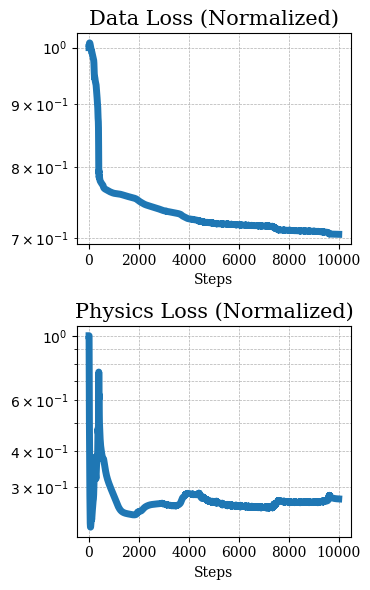

In [9]:
# Loss term progress plot

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
# from pinn.plot import (
    # plot_loss_history_ax,
    # plot_normalized_loss_history_ax,
# )
from pinn.utils import assemble_loss_history



lambda_1 = 1000000
lambda_2 = 100
steps_series = list(range(0, 10001, 100))

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/experimental/TS_105_7/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

assembled_loss = assemble_loss_history(checkpoint_data)
data_loss_norm = assembled_loss["data_loss"] / assembled_loss["data_loss"][0]
physics_loss_norm = assembled_loss["physics_loss"] / assembled_loss["physics_loss"][0]
total_loss_norm = assembled_loss["total_loss"] / assembled_loss["total_loss"][0]

fig = plt.figure(figsize=(3.8*1, 3*2))  # width × height in inches
ax = fig.add_subplot(2, 1, 1)
ax.plot(assembled_loss["step"], data_loss_norm, linestyle='-', linewidth=5)
ax.set_yscale('log')
ax.set_title("Data Loss (Normalized)", fontsize=15, family="serif")
ax.set_xlabel("Steps", family="serif")
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

for label in ax.get_xticklabels():
    label.set_fontfamily("serif")
# for label in ax.get_yticklabels():
#     label.set_fontfamily("serif")

ax = fig.add_subplot(2, 1, 2)
ax.plot(assembled_loss["step"], physics_loss_norm, linestyle='-', linewidth=5)
ax.set_yscale('log')
ax.set_title("Physics Loss (Normalized)", fontsize=15, family="serif")
ax.set_xlabel("Steps", family="serif")
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

for label in ax.get_xticklabels():
    label.set_fontfamily("serif")
# for label in ax.get_yticklabels():
    # label.set_fontfamily("serif")

plt.tight_layout()
# plt.savefig("your_filename.png", dpi=300, bbox_inches="tight")
plt.show()



/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Resizing MRC data from (64, 64, 64) to (128, 128, 128)


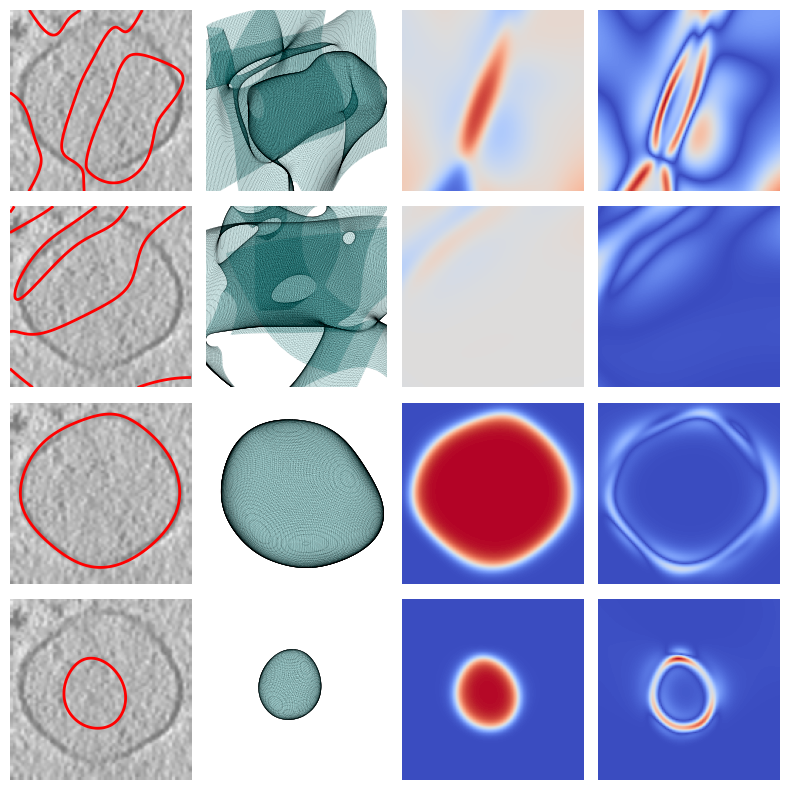

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
    visualize_physics_loss,
)
from pinn.utils import assemble_loss_history
import matplotlib.pyplot as plt

GRID_SIZE = 128
lambda_1 = 1000000
lambda_2_list = [0, 10, 100, 1000]
epsilon = 0.05
step = 1000

# Load checkpoint data
checkpoint_data = {}
for lambda_2 in lambda_2_list:
    checkpoint_dir = os.path.abspath(f"../outputs/logs/experimental/TS_105_7/lambda_{lambda_1}_{lambda_2}")
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[lambda_2] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
# mrc_file_path = "../data/synthetic/biconcave.mrc"
mrc_file_path = "../data/experimental/downsampled/TS_105_7.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)


n = len(lambda_2_list)
fig = plt.figure(figsize=(2*n, 2*4))  # Adjust height accordingly


for i, lambda_2 in enumerate(lambda_2_list):
    # Column 1: CryoET with contours
    ax1 = fig.add_subplot(4, 4, i*4 + 1)
    visualize_cryoET_with_contours(ax1, step, checkpoint_data[lambda_2], cryoET_data,
                                   grid_size=GRID_SIZE, slice_index=64, axis="x", no_label=True)

    # Column 2: 3D Isosurface
    ax2 = fig.add_subplot(4, 4, i*4 + 2, projection='3d')
    plot_3d_isosurface(ax2, step, checkpoint_data[lambda_2], grid_size=GRID_SIZE, no_label=True)

    # Column 3: Placeholder for your 3rd plot type
    ax3 = fig.add_subplot(4, 4, i*4 + 3)
    ax3 = visualize_physics_loss(ax3, epsilon=epsilon, 
                           checkpoint=checkpoint_data[lambda_2], component="phi",
                           grid_size=GRID_SIZE, slice_index=64, axis="x", vmin=-1, vmax=1, no_label=True)

    # Column 4: Placeholder for your 4th plot type
    ax4 = fig.add_subplot(4, 4, i*4 + 4)
    ax4 = visualize_physics_loss(ax4, epsilon=epsilon, 
                           checkpoint=checkpoint_data[lambda_2], component="residual",
                           grid_size=GRID_SIZE, slice_index=64, axis="x", vmin=0, vmax=150, no_label=True)


plt.tight_layout()
# plt.savefig("your_filename.png", dpi=300, bbox_inches="tight")
plt.show()



/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


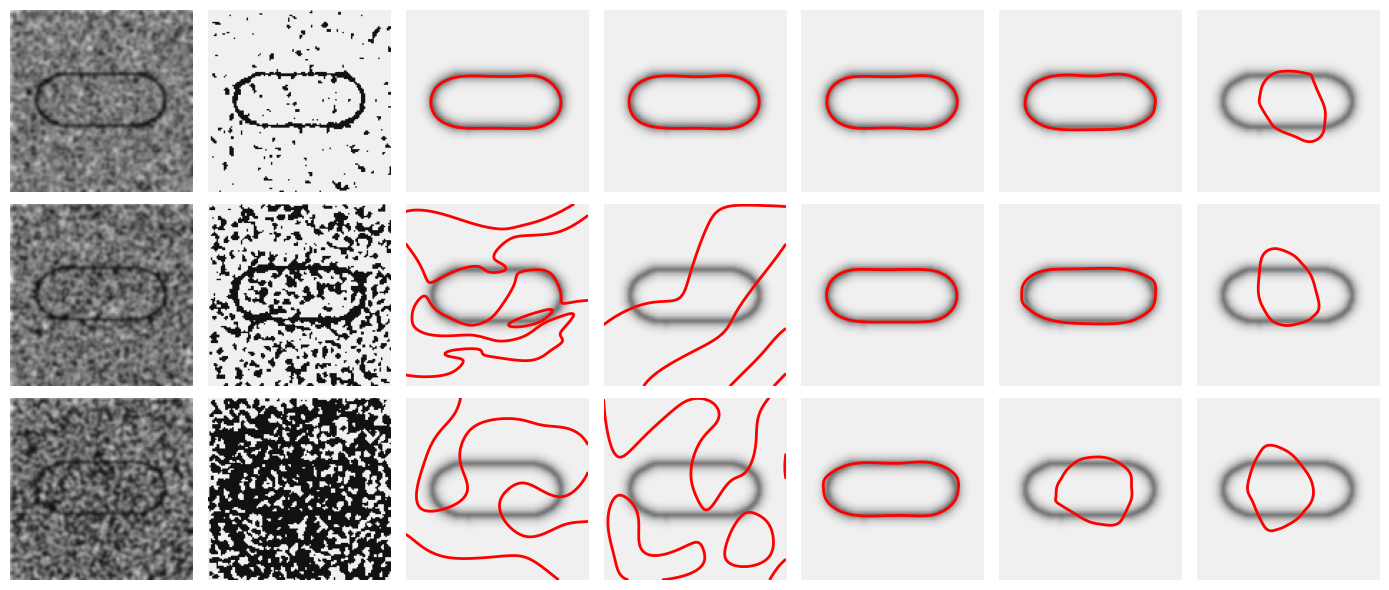

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import visualize_cryoET_with_contours
from data_generation.mesh_to_cryoet import plot_single_slice
import mrcfile

GRID_SIZE = 128
lambda_1 = 1000000
lambda_2_list = [0, 10, 100, 1000, 10000]
flip_ratio_list = [0.1, 0.15, 0.2]
step = 10000
thre = 0.8

# Load checkpoint data
checkpoint_data = {}
for lambda_2 in lambda_2_list:
    checkpoint_data[lambda_2] = {}
    for flip_ratio in flip_ratio_list:
        flip_str = str(flip_ratio).replace('.', '')
        checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/noisy/flip_{flip_str}/lambda_{lambda_1}_{lambda_2}")
        checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
        checkpoint_data[lambda_2][flip_ratio] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load input data
input_data = {}
for flip_ratio in flip_ratio_list:
    flip_str = str(flip_ratio).replace('.', '')
    input_file = f"../data/synthetic/biconcave_noisy_{flip_str}.mrc"
    with mrcfile.open(input_file, permissive=True) as mrc:
        volume = mrc.data
    input_data[flip_ratio] = volume

# Load CryoET data
mrc_file_path = "../data/synthetic/biconcave.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

n = len(lambda_2_list)       # lambda_2 columns
m = len(flip_ratio_list)     # flip_ratio rows
n_col = n+2
fig = plt.figure(figsize=(2*n_col, 2*m))

for i, flip_ratio in enumerate(flip_ratio_list):      # rows

    ax = fig.add_subplot(m, n_col, i * n_col + 1)  # First column in row
    plot_single_slice(input_data[flip_ratio], ax=ax, axis="z", slice_index=64, thre=None, show_title=False) 

    ax = fig.add_subplot(m, n_col, i * n_col + 2)  # Second column in row
    plot_single_slice(input_data[flip_ratio], ax=ax, axis="z", slice_index=64, thre=0.8, show_title=False) 

    for j, lambda_2 in enumerate(lambda_2_list):      # columns
        ax = fig.add_subplot(m, n_col, i * n_col + j + 3)  # +2 to skip left column
        visualize_cryoET_with_contours(
            ax, step, checkpoint_data[lambda_2][flip_ratio], cryoET_data,
            grid_size=GRID_SIZE, slice_index=64, axis="z", no_label=True
        )


plt.tight_layout()
# plt.savefig("your_filename.png", dpi=300, bbox_inches="tight")
plt.show()

